In [108]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# EfficientNet expects 224x224 and ImageNet normalization
IMG_SIZE=224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    ])
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    ])


def get_dataloaders(data_dir, batch_size=32, shuffle=True, transform=val_transform):
    # standard preprocessing for VAEs

    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    # AFHQ structure is usually: 0:cat, 1:dog, 2:wild
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    images, labels = next(iter(dataloader))
    
    # Pick only the cats from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: return
    
    cats = images[cat_indices[:4]].to(device)
    
    with torch.no_grad():
        # 1. Encode Cats
        mu, _ = model.encode(cats, torch.zeros(len(cats), dtype=torch.long).to(device))
        
        # 2. Decode as Dogs (Label 1)
        dog_labels = torch.ones(len(cats), dtype=torch.long).to(device)
        transformed_dogs = model.decode(mu, dog_labels)

    # Plotting
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(len(cats)):
        # Show Original Cat
        orig = cats[i].cpu() #* 0.5 + 0.5
        axes[0, i].imshow(np.transpose(orig, (1, 2, 0)))
        axes[0, i].set_title("Original Cat")
        axes[0, i].axis('off')
        
        # Show Transformed Dog
        trans = transformed_dogs[i].cpu() #* 0.5 + 0.5
        axes[1, i].imshow(np.transpose(trans, (1, 2, 0)))
        axes[1, i].set_title("Transformed Dog")
        axes[1, i].axis('off')
    plt.show()

In [109]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

In [110]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import squeezenet1_1, SqueezeNet1_1_Weights

class efficientCVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2, img_channels=3, emb_dim=64):
        super(efficientCVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_emb = nn.Embedding(num_classes, emb_dim)

        # SqueezeNet encoder (fast)
        weights = SqueezeNet1_1_Weights.DEFAULT
        self.sq = squeezenet1_1(weights=weights)
        self.encoder_backbone = self.sq.features

        # determine encoder feature vector size by passing a dummy
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feat = self.encoder_backbone(dummy)
            feat_c = feat.shape[1]

        # encoder heads
        self.fc_mu = nn.Linear(feat_c + emb_dim, latent_dim)
        self.fc_logvar = nn.Linear(feat_c + emb_dim, latent_dim)

        # decoder (start from 512 x 7 x 7 like before)
        self.decoder_input = nn.Linear(latent_dim + emb_dim, 512 * 7 * 7)

        self.decoder = nn.Sequential(
            self._make_decoder_block(512, 256),  # 7->14
            self._make_decoder_block(256, 128),  # 14->28
            self._make_decoder_block(128, 64),   # 28->56
            self._make_decoder_block(64, 32),    # 56->112
            nn.ConvTranspose2d(32, img_channels, 4, 2, 1),  # 112->224
            nn.Sigmoid()
        )

    def _make_decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def encode(self, x, y):
        features = self.encoder_backbone(x)            # [B, C, H, W]
        features = torch.mean(features, dim=[2, 3])   # [B, C]
        y_emb = self.label_emb(y)
        h = torch.cat([features, y_emb], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z_cond = torch.cat([z, y_emb], dim=1)
        out = self.decoder_input(z_cond)
        out = out.view(-1, 512, 7, 7)
        return self.decoder(out)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

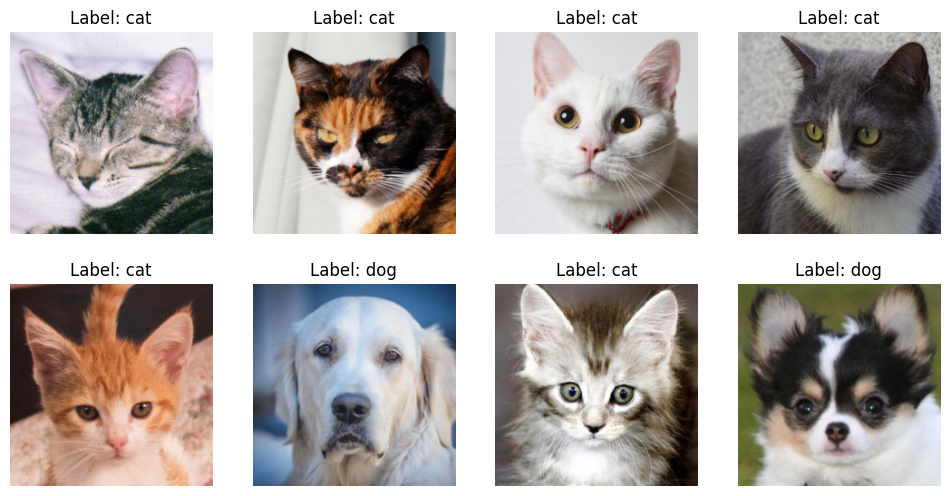

In [111]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")

# Initialize Model (from previous code)
model = efficientCVAE(latent_dim=128).to(device)

# 1. Peek at your database
show_batch(train_loader, train_classes)

# 2. (After training) Check transformations
# visualize_transformation(model, data_loader, device)

# Training util functions

In [112]:
import torchvision.models as models

def get_cyclical_beta(epoch, total_epochs, n_cycles=4, ratio=0.5):
    """
    Generates a cyclical beta value.
    n_cycles: Number of times beta goes from 0 to 1.
    ratio: Proportion of each cycle spent increasing (rest of cycle stays at 1.0).
    """
    period = total_epochs / n_cycles
    step = epoch % period
    
    # Calculate the ramp
    if step < period * ratio:
        return step / (period * ratio)
    else:
        return 1.0
    

def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss (MSE or BCE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence: forces latent space to be normal distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss * beta
def sharp_loss_function(recon_x, x, mu, logvar):
    # BCE Loss: Penalizes "gray" blurry pixels heavily.
    # reduction='sum' ensures the reconstruction gradient is strong enough to overpower the KL regularization
    bce_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL Divergence
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return bce_loss + kld_loss

In [113]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs):
    model.train()
    train_loss = 0
    beta = min(0.1, epoch / 10.0)
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)
        if batch_idx == 0 and epoch == 1:
            if data.max() > 1.0 or data.min() < -1.0:
                print(f"WARNING: Data range is [{data.min()}, {data.max()}]. Model expects [-1, 1]")
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data, labels)
        # Calculate loss
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            recon_batch, mu, logvar = model(data, labels)
            loss = loss_function(recon_batch, data, mu, logvar)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss

# Training Loop

Epoch 1: Train Loss: 10586.8884 | Val Loss: 10737.5304 | LR: 0.001
Saved best model
Epoch 2: Train Loss: 8177.0707 | Val Loss: 7199.9712 | LR: 0.001
Saved best model
Epoch 3: Train Loss: 6525.5790 | Val Loss: 6148.8400 | LR: 0.001
Saved best model
Epoch 4: Train Loss: 5475.2412 | Val Loss: 5843.6755 | LR: 0.001
Saved best model
Epoch 5: Train Loss: 5166.4458 | Val Loss: 5413.6944 | LR: 0.001
Saved best model
Epoch 6: Train Loss: 5166.5182 | Val Loss: 5529.4382 | LR: 0.001
Epoch 7: Train Loss: 4932.2321 | Val Loss: 5353.7264 | LR: 0.001
Saved best model
Epoch 8: Train Loss: 4883.2331 | Val Loss: 5330.3943 | LR: 0.001
Saved best model
Epoch 9: Train Loss: 4737.4339 | Val Loss: 5140.5023 | LR: 0.001
Saved best model
Epoch 10: Train Loss: 4703.2306 | Val Loss: 5337.4325 | LR: 0.001

--- Cat->Dog Interpolation at Epoch 10 ---


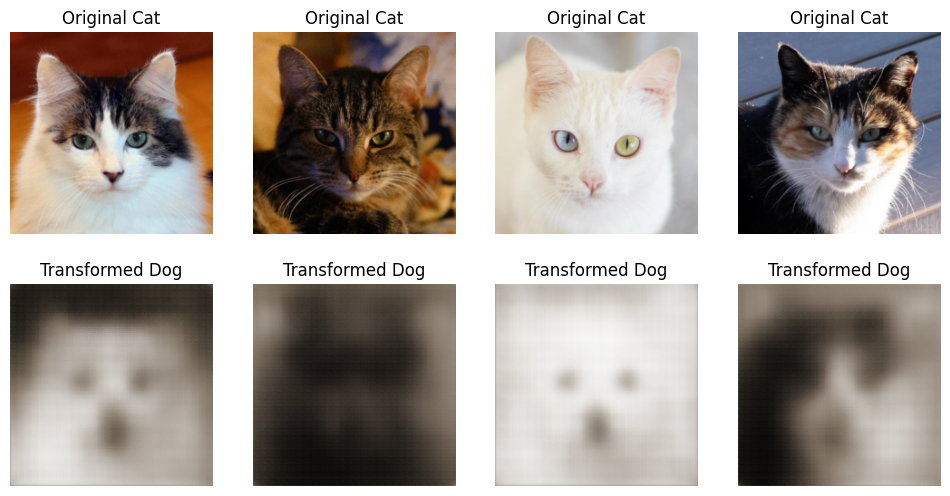


Epoch 11: Train Loss: 4519.6318 | Val Loss: 4868.5321 | LR: 0.001
Saved best model
Epoch 12: Train Loss: 4350.5185 | Val Loss: 5300.0247 | LR: 0.001
Epoch 13: Train Loss: 4281.4306 | Val Loss: 4794.0454 | LR: 0.001
Saved best model
Epoch 14: Train Loss: 4191.0662 | Val Loss: 4574.7480 | LR: 0.001
Saved best model
Epoch 15: Train Loss: 4057.7063 | Val Loss: 4592.7458 | LR: 0.001
Epoch 16: Train Loss: 4012.6733 | Val Loss: 4466.8766 | LR: 0.001
Saved best model
Epoch 17: Train Loss: 3968.1946 | Val Loss: 4669.6612 | LR: 0.001
Epoch 18: Train Loss: 3983.8865 | Val Loss: 4617.5789 | LR: 0.001
Epoch 19: Train Loss: 3908.3207 | Val Loss: 4647.2117 | LR: 0.001
Epoch 20: Train Loss: 3897.6944 | Val Loss: 4450.8188 | LR: 0.001
Saved best model

--- Cat->Dog Interpolation at Epoch 20 ---


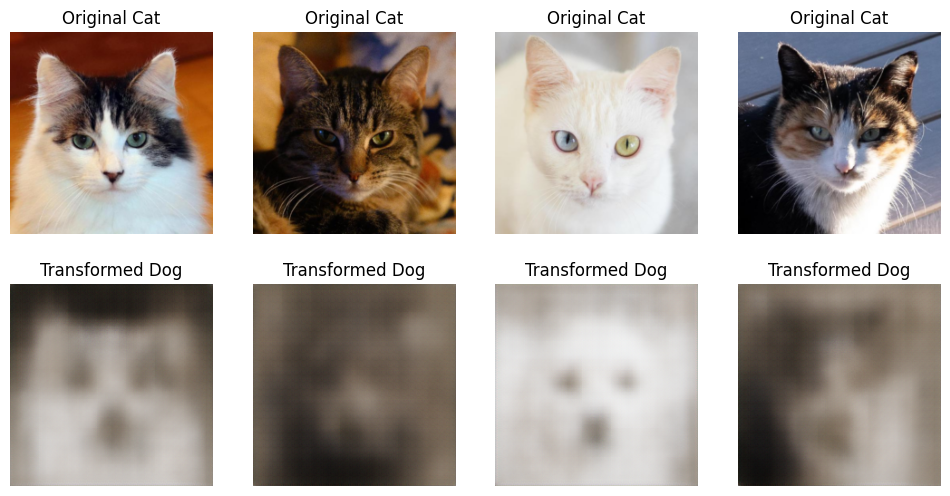


Epoch 21: Train Loss: 3845.9380 | Val Loss: 4387.2091 | LR: 0.001
Saved best model
Epoch 22: Train Loss: 3820.2805 | Val Loss: 4658.2109 | LR: 0.001
Epoch 23: Train Loss: 3741.2604 | Val Loss: 4359.0063 | LR: 0.001
Saved best model
Epoch 24: Train Loss: 3809.8366 | Val Loss: 4367.5827 | LR: 0.001
Epoch 25: Train Loss: 3721.6652 | Val Loss: 4230.9575 | LR: 0.001
Saved best model
Epoch 26: Train Loss: 3732.9477 | Val Loss: 5119.0364 | LR: 0.001
Epoch 27: Train Loss: 3637.3711 | Val Loss: 4206.2760 | LR: 0.001
Saved best model
Epoch 28: Train Loss: 3614.3308 | Val Loss: 4337.3470 | LR: 0.001
Epoch 29: Train Loss: 3656.1634 | Val Loss: 4381.9544 | LR: 0.001
Epoch 30: Train Loss: 3558.4506 | Val Loss: 4160.3330 | LR: 0.001
Saved best model

--- Cat->Dog Interpolation at Epoch 30 ---


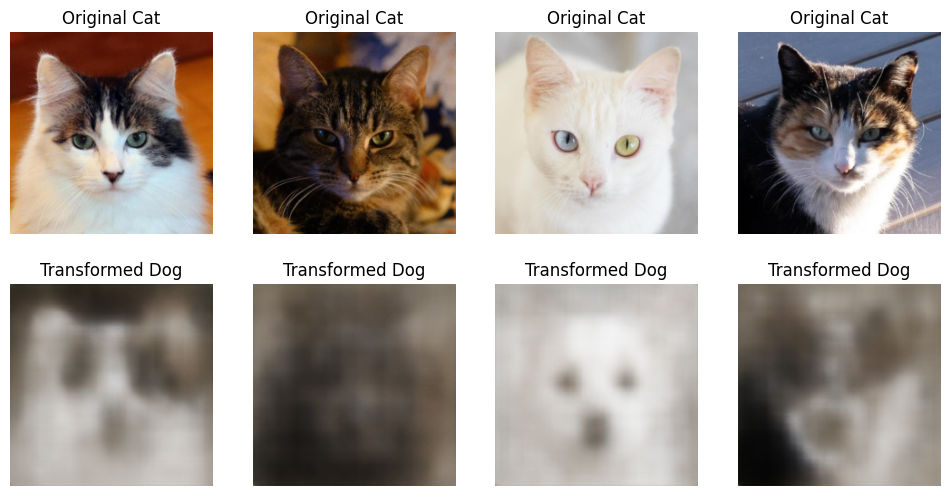


Epoch 31: Train Loss: 3531.2850 | Val Loss: 4218.0162 | LR: 0.001
Epoch 32: Train Loss: 3493.6690 | Val Loss: 4353.5405 | LR: 0.001
Epoch 33: Train Loss: 3452.2112 | Val Loss: 4377.7252 | LR: 0.001
Epoch 34: Train Loss: 3462.4629 | Val Loss: 4215.5398 | LR: 0.001
Epoch 35: Train Loss: 3412.8755 | Val Loss: 4592.6916 | LR: 0.001
Epoch 36: Train Loss: 3399.0831 | Val Loss: 4266.9188 | LR: 0.001
Epoch 37: Train Loss: 3334.6090 | Val Loss: 4049.3010 | LR: 0.001
Saved best model
Epoch 38: Train Loss: 3291.9306 | Val Loss: 4027.6261 | LR: 0.001
Saved best model
Epoch 39: Train Loss: 3248.5705 | Val Loss: 4053.0061 | LR: 0.001
Epoch 40: Train Loss: 3256.2381 | Val Loss: 4408.5357 | LR: 0.001

--- Cat->Dog Interpolation at Epoch 40 ---


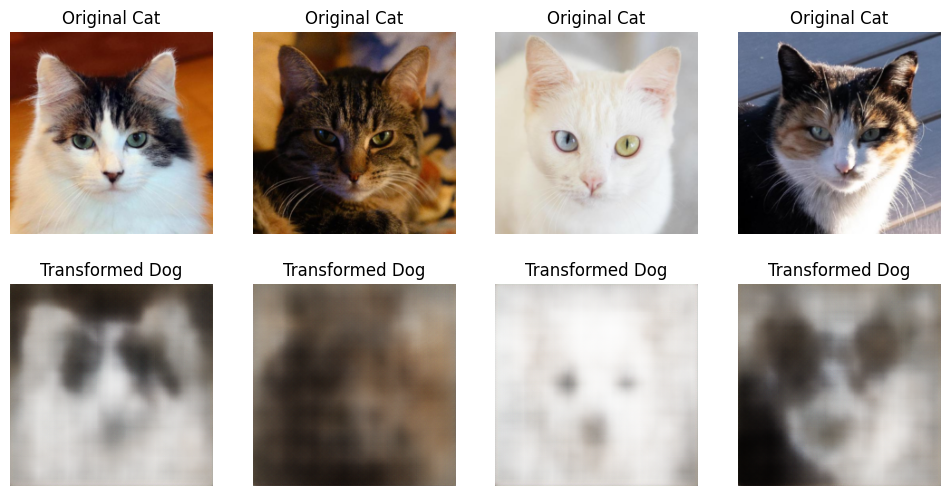


Epoch 41: Train Loss: 3266.5083 | Val Loss: 3894.3836 | LR: 0.001
Saved best model
Epoch 42: Train Loss: 3187.4336 | Val Loss: 3984.0294 | LR: 0.001
Epoch 43: Train Loss: 3169.4805 | Val Loss: 4354.3516 | LR: 0.001
Epoch 44: Train Loss: 3112.0966 | Val Loss: 4035.3521 | LR: 0.001
Epoch 45: Train Loss: 3064.2198 | Val Loss: 3905.8249 | LR: 0.001
Epoch 46: Train Loss: 3004.6992 | Val Loss: 3843.2697 | LR: 0.001
Saved best model
Epoch 47: Train Loss: 2949.3920 | Val Loss: 3925.1838 | LR: 0.001
Epoch 48: Train Loss: 2984.0656 | Val Loss: 4806.7846 | LR: 0.001
Epoch 49: Train Loss: 2932.4999 | Val Loss: 3797.5656 | LR: 0.001
Saved best model
Epoch 50: Train Loss: 2856.3986 | Val Loss: 4841.7322 | LR: 0.001

--- Cat->Dog Interpolation at Epoch 50 ---


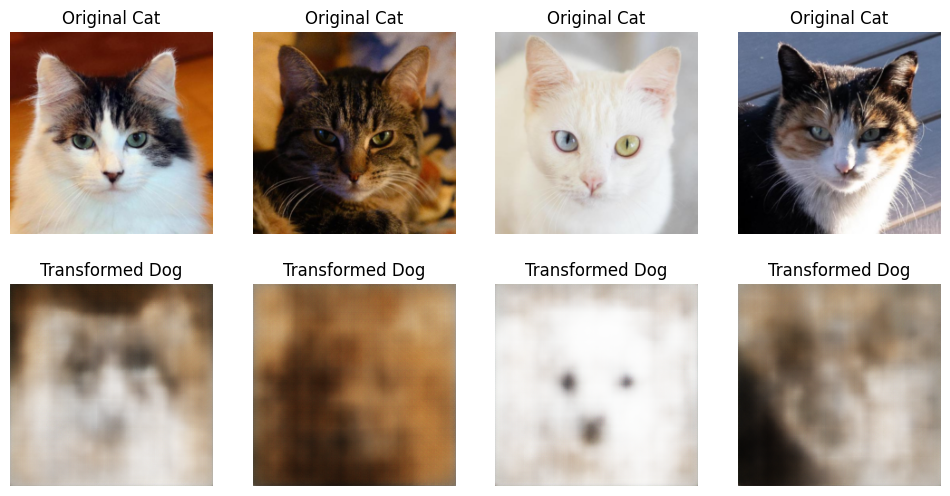

In [114]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train",transform=aug_transform)
val_loader, val_classes = get_dataloaders("./afhq/val",shuffle=False)

# --- Configuration ---
num_epochs = 50
learning_rate = 1e-03  # start at 0.01

# Initialize Model and Optimizer
model = efficientCVAE(latent_dim=256, num_classes=2, img_channels=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Scheduler: decrease every 5 epochs so lr at epoch 15 == 0.001
gamma = (0.001 / learning_rate) ** (1/3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=gamma)

best_val_loss=np.inf
# --- Main Loop ---
for epoch in range(1, num_epochs + 1):
    # Call training function
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    
    # Call validation function
    val_loss = validate_epoch(model, val_loader, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]["lr"]:.6g}')

    if val_loss<best_val_loss:
        best_val_loss = val_loss
        print("Saved best model")
        state_dict = deepcopy(model.state_dict())

    if epoch % 10 == 0:
        print(f"\n--- Cat->Dog Interpolation at Epoch {epoch} ---")
        visualize_transformation(model, val_loader, device)
        print()
    
    # step scheduler at end of epoch
    scheduler.step()
    
    torch.save(model.state_dict(), f"cvae_epoch_{epoch}.pth")

# Visualize trained model output

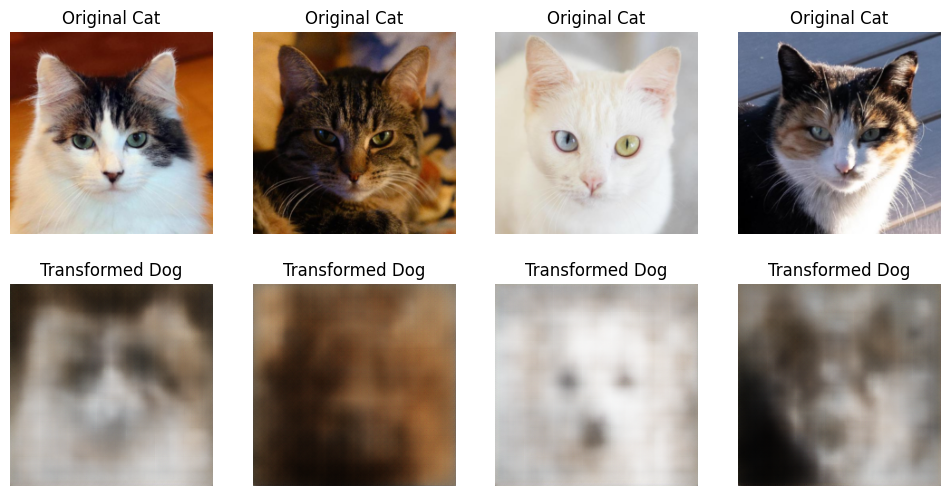

In [115]:
# Load best model
model.load_state_dict(state_dict)
visualize_transformation(model, val_loader, device)

In [116]:
def show_generated_image(model, label):
    z = torch.randn(1, 256).to(device)
    y = torch.tensor([label]).to(device)
    
    # Generate
    recon = model.decode(z, y)
    
    # Move to CPU and format for Plotting (Channels Last)
    # Shape becomes (64, 64, 3)
    img = recon[0].permute(1, 2, 0).detach().cpu().numpy()
    
    plt.imshow(img) # Matplotlib treats 0.0-1.0 as valid RGB colors
    plt.title(f"Generated Class {label}")
    plt.show()

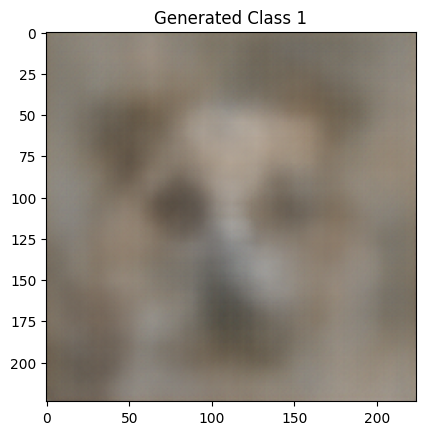

In [117]:
show_generated_image(model, 1)